# ATLAS — Dataset Analysis

**What this notebook does:**
1. Inspects TextGrid structure (tiers, annotation levels)
2. Checks if technique annotations are coarse (track-level) or fine-grained (phoneme/word-level)
3. Analyses annotation coverage across singers and techniques
4. Visualises lyrics aligned to audio (waveform + word boundaries)
5. Produces summary statistics about the dataset structure

**Output:** `metadata2/atlas_dataset_analysis.csv` + visualisations

## 0. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuration

In [3]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/atlas")
META_CSV    = PROJECT_DIR / "metadata2" / "atlas_english_metadata.csv"
META_DIR    = PROJECT_DIR / "metadata2"

LOCAL_DIR   = Path("/content/atlas")
EXTRACT_DIR = LOCAL_DIR / "English_raw"

print(f"META_CSV exists : {META_CSV.exists()}")
print(f"Extract dir     : {EXTRACT_DIR}")
print(f"Extracted       : {EXTRACT_DIR.exists() and any(EXTRACT_DIR.rglob('*.wav'))}")

META_CSV exists : True
Extract dir     : /content/atlas/English_raw
Extracted       : False


## 2. Install Dependencies

In [4]:
!pip install -q tgt pandas matplotlib librosa soundfile

import tgt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import librosa
import soundfile as sf
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm

print("Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 1.7 MB/s eta 0:00:00
Dependencies ready


## 3. Unzip Dataset (if needed)

In [5]:
import zipfile

ZIP_PATH = PROJECT_DIR / "English.zip"
already_extracted = EXTRACT_DIR.exists() and any(EXTRACT_DIR.rglob("*.wav"))

if already_extracted:
    all_wavs = list(EXTRACT_DIR.rglob("*.wav"))
    print(f"Already extracted — {len(all_wavs):,} WAV files")
else:
    print("Unzipping...")
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        from tqdm.notebook import tqdm as tqdm_nb
        for member in tqdm_nb(zf.namelist(), desc="Extracting"):
            zf.extract(member, EXTRACT_DIR)
    print("Done")

Unzipping...


Extracting:   0%|          | 0/25984 [00:00<?, ?it/s]

Done


## 4. Inspect TextGrid Structure

Let's look at what tiers exist inside the TextGrids and what kind of annotations they contain.

In [6]:
# Find all TextGrid files
all_tgs = list(EXTRACT_DIR.rglob("*.TextGrid"))
print(f"Total TextGrid files: {len(all_tgs):,}")

# Inspect the first few
tier_names_seen = defaultdict(int)
tier_types_seen = defaultdict(int)

sample_tgs = all_tgs[:200]

for tg_path in sample_tgs:
    try:
        tg = tgt.io.read_textgrid(str(tg_path))
        for tier in tg.tiers:
            tier_names_seen[tier.name] += 1
            tier_types_seen[type(tier).__name__] += 1
    except Exception:
        pass

print("\nTier names found (top 20):")
for name, count in sorted(tier_names_seen.items(), key=lambda x: -x[1])[:20]:
    print(f"  {name:<30} {count:>5}x")

print("\nTier types:")
for t, count in tier_types_seen.items():
    print(f"  {t}: {count}")

Total TextGrid files: 5,211

Tier names found (top 20):
  word                             200x
  phone                            200x
  mix                              125x
  falsetto                         125x
  breathy                          125x
  pharyngeal                       125x
  vibrato                          125x
  glissando                        125x
  global                           125x

Tier types:
  IntervalTier: 1275


In [7]:
# Open one TextGrid example and print full structure
example_tg = all_tgs[0]
print(f"Example: {example_tg}")
print()

tg = tgt.io.read_textgrid(str(example_tg))
print(f"Duration: {tg.end_time:.3f}s")
print(f"Number of tiers: {len(tg.tiers)}")
print()

for tier in tg.tiers:
    print(f"Tier: '{tier.name}' ({type(tier).__name__})")
    intervals = tier.intervals if hasattr(tier, 'intervals') else list(tier)
    non_empty = [iv for iv in intervals if iv.text.strip()]
    print(f"  Total intervals: {len(intervals)}, Non-empty: {len(non_empty)}")
    print(f"  First 5 non-empty: {[iv.text for iv in non_empty[:5]]}")
    if non_empty:
        durations = [(iv.end_time - iv.start_time)*1000 for iv in non_empty]
        print(f"  Duration range: {min(durations):.0f}ms – {max(durations):.0f}ms")
    print()

Example: /content/atlas/English_raw/English/EN-Tenor-1/Breathy/Million Reasons/Paired_Speech_Group/0002.TextGrid

Duration: 9.242s
Number of tiers: 2

Tier: 'word' (IntervalTier)
  Total intervals: 32, Non-empty: 32
  First 5 non-empty: ['about', 'a', 'million', 'reasons', '<SP>']
  Duration range: 30ms – 600ms

Tier: 'phone' (IntervalTier)
  Total intervals: 82, Non-empty: 82
  First 5 non-empty: ['AH0', 'B', 'AW1', 'T', 'AH0']
  Duration range: 30ms – 570ms



In [8]:
# Find a Technique Group TextGrid
example_tg = next(p for p in all_tgs if any(
    kw in str(p) for kw in ["Vibrato_Group", "Glissando_Group", "Breathy_Group",
                              "Pharyngeal_Group", "Mixed_Voice_Group"]
))

tg = tgt.io.read_textgrid(str(example_tg))
print(f"Example: {example_tg}")
print(f"Duration: {tg.end_time:.3f}s")
print(f"Number of tiers: {len(tg.tiers)}")
print()

for tier in tg.tiers:
    intervals = tier.intervals if hasattr(tier, 'intervals') else list(tier)
    non_empty = [iv for iv in intervals if iv.text.strip()]
    print(f"Tier: '{tier.name}'")
    print(f"  Annotations: {len(non_empty)}")
    print(f"  Labels: {list(set(iv.text for iv in non_empty))[:10]}")
    print()

Example: /content/atlas/English_raw/English/EN-Tenor-1/Breathy/Million Reasons/Breathy_Group/0002.TextGrid
Duration: 10.466s
Number of tiers: 9

Tier: 'word'
  Annotations: 28
  Labels: ['about', 'reasons', 'you', "i'd", 'for', 'run', 'would', 'be', 'hills', 'highway']

Tier: 'phone'
  Annotations: 78
  Labels: ['Y', 'Z', 'IY0', 'T', 'R', 'K', 'UH1', 'S', 'AH0', 'ER0']

Tier: 'mix'
  Annotations: 78
  Labels: ['0']

Tier: 'falsetto'
  Annotations: 78
  Labels: ['0', '1']

Tier: 'breathy'
  Annotations: 78
  Labels: ['0', '1']

Tier: 'pharyngeal'
  Annotations: 78
  Labels: ['0']

Tier: 'vibrato'
  Annotations: 78
  Labels: ['0']

Tier: 'glissando'
  Annotations: 78
  Labels: ['0', '1']

Tier: 'global'
  Annotations: 1
  Labels: ['pop, fast, medium, happy']



## 5. Coarse vs Fine-Grained Annotations

Check if technique annotations are at phoneme level, word level, or track level.

In [9]:
# Analyse annotation granularity across a sample
results = []

for tg_path in tqdm(all_tgs[:500], desc="Analysing TextGrids"):
    try:
        tg = tgt.io.read_textgrid(str(tg_path))
        path_parts = tg_path.parts

        # Get singer and technique from path
        singer = next((p for p in path_parts if "EN-" in p), "unknown")
        duration = tg.end_time

        tier_info = {}
        for tier in tg.tiers:
            intervals = tier.intervals if hasattr(tier, 'intervals') else list(tier)
            non_empty = [iv for iv in intervals if iv.text.strip() and
                         iv.text.strip().lower() not in ["sil", "sp", "<sil>", "spn"]]
            tier_info[tier.name] = len(non_empty)

        results.append({
            "tg_path":    str(tg_path),
            "singer":     singer,
            "duration_s": round(duration, 3),
            "n_tiers":    len(tg.tiers),
            "tier_names": "|".join(t.name for t in tg.tiers),
            **{f"n_{k}": v for k, v in tier_info.items()},
        })
    except Exception:
        pass

df_tg = pd.DataFrame(results)
print(f"Analysed {len(df_tg)} TextGrids")
print()
print("Tier name combinations:")
print(df_tg["tier_names"].value_counts().head(10).to_string())

Analysing TextGrids:   0%|          | 0/500 [00:00<?, ?it/s]

Analysed 500 TextGrids

Tier name combinations:
tier_names
word|phone|mix|falsetto|breathy|pharyngeal|vibrato|glissando|global    339
word|phone                                                             161


In [10]:
# Summary: how many annotations per tier on average?
tier_cols = [c for c in df_tg.columns if c.startswith("n_") and c != "n_tiers"]

print("Average annotations per utterance per tier:")
for col in tier_cols:
    mean_val = df_tg[col].mean()
    print(f"  {col:<25} {mean_val:.1f}")

print()
print("Average utterance duration:")
print(f"  Mean: {df_tg['duration_s'].mean():.2f}s")
print(f"  Min:  {df_tg['duration_s'].min():.2f}s")
print(f"  Max:  {df_tg['duration_s'].max():.2f}s")

Average annotations per utterance per tier:
  n_word                    14.5
  n_phone                   39.4
  n_mix                     39.1
  n_falsetto                39.1
  n_breathy                 39.1
  n_pharyngeal              39.1
  n_vibrato                 39.1
  n_glissando               39.1
  n_global                  1.0

Average utterance duration:
  Mean: 7.58s
  Min:  1.18s
  Max:  24.88s


## 6. Phoneme Duration Analysis by Technique

Singing phonemes (especially vowels) are much longer than speech. This is why ASR systems fail.

In [ ]:
GROUP_KEYWORDS = {
    "Vibrato_Group": "vibrato", "Glissando_Group": "glissando",
    "Breathy_Group": "technique", "Pharyngeal_Group": "technique",
    "Mixed_Voice_Group": "technique", "Falsetto_Group": "technique",
    "Control_Group": "control", "Paired_Speech_Group": "speech"
}

TECHNIQUE_KEYWORDS = {
    "Vibrato": "vibrato", "Glissando": "glissando", "Breathy": "breathy",
    "Pharyngeal": "pharyngeal", "Mixed_Voice": "mixed_voice",
    "Mixed_Voice_and_Falsetto": "mixed_voice",
}

def get_technique(parts):
    for part in parts:
        for kw, label in TECHNIQUE_KEYWORDS.items():
            if kw.lower() in part.lower():
                return label
    return "unknown"

def get_group(parts):
    for part in parts:
        for kw, label in GROUP_KEYWORDS.items():
            if kw.lower() in part.lower():
                return label
    return "unknown"

phone_records = []

for tg_path in tqdm(all_tgs[:800], desc="Extracting phoneme durations"):
    try:
        tg  = tgt.io.read_textgrid(str(tg_path))
        parts = tg_path.parts
        technique = get_technique(list(parts))
        group     = get_group(list(parts))
        singer    = next((p for p in parts if "EN-" in p), "unknown")

        for tier in tg.tiers:
            if "phone" in tier.name.lower():
                intervals = tier.intervals if hasattr(tier, 'intervals') else list(tier)
                for iv in intervals:
                    txt = iv.text.strip()
                    if txt and txt.lower() not in ["sil", "sp", "<sil>", "spn", ""]:
                        dur_ms = (iv.end_time - iv.start_time) * 1000
                        # Classify as vowel or consonant
                        is_vowel = any(v in txt.upper()[:2] for v in ["AA","AE","AH","AO","AW","AY",
                                                                        "EH","ER","EY","IH","IY","OW",
                                                                        "OY","UH","UW"])
                        phone_records.append({
                            "phoneme":   txt,
                            "dur_ms":    dur_ms,
                            "technique": technique,
                            "group":     group,
                            "singer":    singer,
                            "is_vowel":  is_vowel,
                        })
    except Exception:
        pass

df_ph = pd.DataFrame(phone_records)
print(f"Total phoneme instances: {len(df_ph):,}")
print()
print("Mean phoneme duration by group:")
print(df_ph.groupby("group")["dur_ms"].mean().round(1).to_string())

Extracting phoneme durations:   0%|          | 0/800 [00:00<?, ?it/s]

Total phoneme instances: 33,147

Mean phoneme duration by group:
group
control      224.5
speech       111.0
technique    216.0


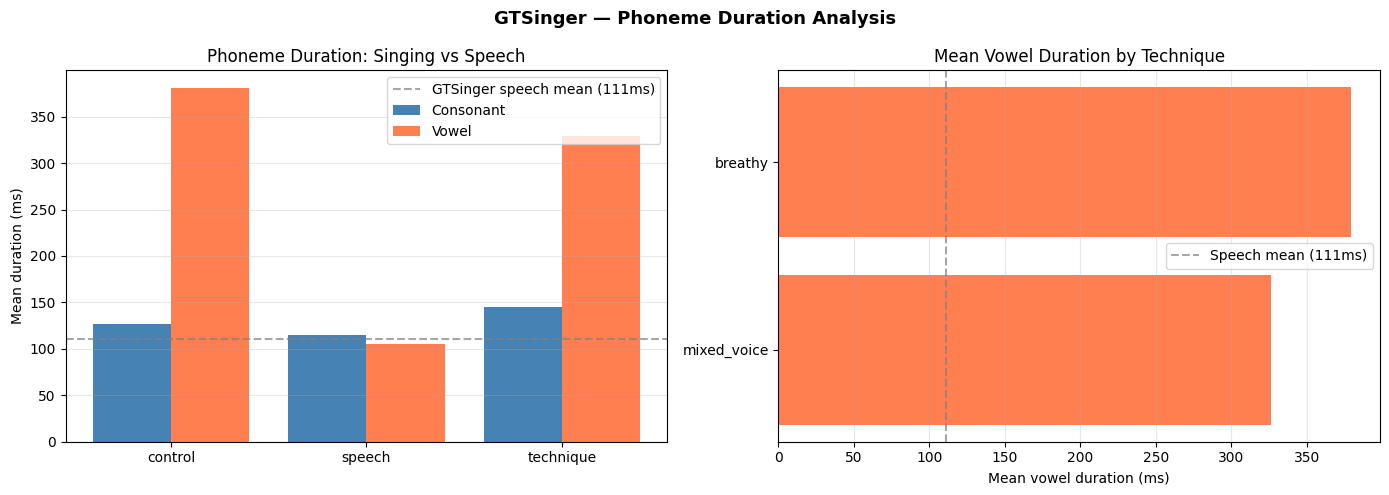

Saved → /content/drive/MyDrive/atlas/metadata2/phoneme_duration_analysis.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GTSinger — Phoneme Duration Analysis", fontsize=13, fontweight="bold")

# Compute speech mean for reference line
speech_mean = df_ph[df_ph["group"] == "speech"]["dur_ms"].mean()

# Plot 1: Mean phoneme duration by group (singing vs speech)
ax = axes[0]
grp_dur = df_ph.groupby(["group", "is_vowel"])["dur_ms"].mean().unstack()
grp_dur.columns = ["Consonant", "Vowel"]
grp_dur = grp_dur[grp_dur.index.isin(["control", "technique", "speech"])]
x = np.arange(len(grp_dur))
ax.bar(x - 0.2, grp_dur["Consonant"], 0.4, label="Consonant", color="steelblue")
ax.bar(x + 0.2, grp_dur["Vowel"],     0.4, label="Vowel",     color="coral")
ax.set_xticks(x)
ax.set_xticklabels(grp_dur.index)
ax.set_ylabel("Mean duration (ms)")
ax.set_title("Phoneme Duration: Singing vs Speech")
ax.legend()
ax.axhline(speech_mean, color="gray", linestyle="--", alpha=0.7,
           label=f"GTSinger speech mean ({speech_mean:.0f}ms)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Plot 2: Vowel duration by technique
ax = axes[1]
vowels = df_ph[df_ph["is_vowel"] & df_ph["group"].isin(["control", "technique"])]
tech_dur = vowels.groupby("technique")["dur_ms"].mean().sort_values(ascending=True)
ax.barh(range(len(tech_dur)), tech_dur.values, color="coral")
ax.set_yticks(range(len(tech_dur)))
ax.set_yticklabels(tech_dur.index)
ax.set_xlabel("Mean vowel duration (ms)")
ax.set_title("Mean Vowel Duration by Technique")
ax.axvline(speech_mean, color="gray", linestyle="--", alpha=0.7,
           label=f"Speech mean ({speech_mean:.0f}ms)")
ax.legend()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plot_path = META_DIR / "phoneme_duration_analysis.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {plot_path}")

## 7. Lyrics Alignment Visualisation

Plot waveform + word/phoneme boundaries for a sample utterance (like Sonic Visualizer but in Python).

In [14]:
def plot_alignment(wav_path: str, tg_path: str, title: str = ""):
    """Plot waveform with word and phoneme boundaries from TextGrid."""
    # Load audio
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    duration = len(y) / sr
    times = np.linspace(0, duration, len(y))

    # Load TextGrid
    tg = tgt.io.read_textgrid(tg_path)

    # Find word and phone tiers
    word_tier  = next((t for t in tg.tiers if "word" in t.name.lower()), None)
    phone_tier = next((t for t in tg.tiers if "phone" in t.name.lower()), None)

    n_plots = 1 + (word_tier is not None) + (phone_tier is not None)
    fig, axes = plt.subplots(n_plots, 1, figsize=(16, 3 * n_plots),
                              gridspec_kw={"height_ratios": [2] + [1]*(n_plots-1)})
    if n_plots == 1:
        axes = [axes]

    fig.suptitle(title or wav_path, fontsize=11, fontweight="bold")

    # Plot waveform
    ax = axes[0]
    ax.plot(times, y, color="steelblue", linewidth=0.5, alpha=0.8)
    ax.set_xlim(0, duration)
    ax.set_ylabel("Amplitude")
    ax.set_title("Waveform")
    ax.grid(alpha=0.2)

    # Plot word tier
    if word_tier is not None:
        ax = axes[1]
        ax.set_xlim(0, duration)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_title(f"Word tier: '{word_tier.name}'")
        colors = plt.cm.Set3(np.linspace(0, 1, 12))
        intervals = word_tier.intervals if hasattr(word_tier, 'intervals') else list(word_tier)
        for i, iv in enumerate(intervals):
            txt = iv.text.strip()
            if txt and txt.lower() not in ["sil", "sp"]:
                ax.axvspan(iv.start_time, iv.end_time,
                           alpha=0.4, color=colors[i % 12])
                mid = (iv.start_time + iv.end_time) / 2
                ax.text(mid, 0.5, txt, ha="center", va="center",
                        fontsize=8, fontweight="bold")
            ax.axvline(iv.start_time, color="gray", linewidth=0.5, alpha=0.5)
        ax.grid(alpha=0.2)

    # Plot phone tier
    if phone_tier is not None:
        ax = axes[-1]
        ax.set_xlim(0, duration)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_xlabel("Time (s)")
        ax.set_title(f"Phone tier: '{phone_tier.name}'")
        intervals = phone_tier.intervals if hasattr(phone_tier, 'intervals') else list(phone_tier)
        for iv in intervals:
            txt = iv.text.strip()
            ax.axvline(iv.start_time, color="darkred", linewidth=0.5, alpha=0.4)
            if txt and txt.lower() not in ["sil", "sp"]:
                mid = (iv.start_time + iv.end_time) / 2
                ax.text(mid, 0.5, txt, ha="center", va="center",
                        fontsize=7, color="darkred")
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

print("Visualisation function ready")

Visualisation function ready



--- CONTROL ---
Singer: EN-Tenor-1, Technique: pharyngeal
GT Lyrics: i'm falling <SP> in all the good times i find myself longing for change <AP>


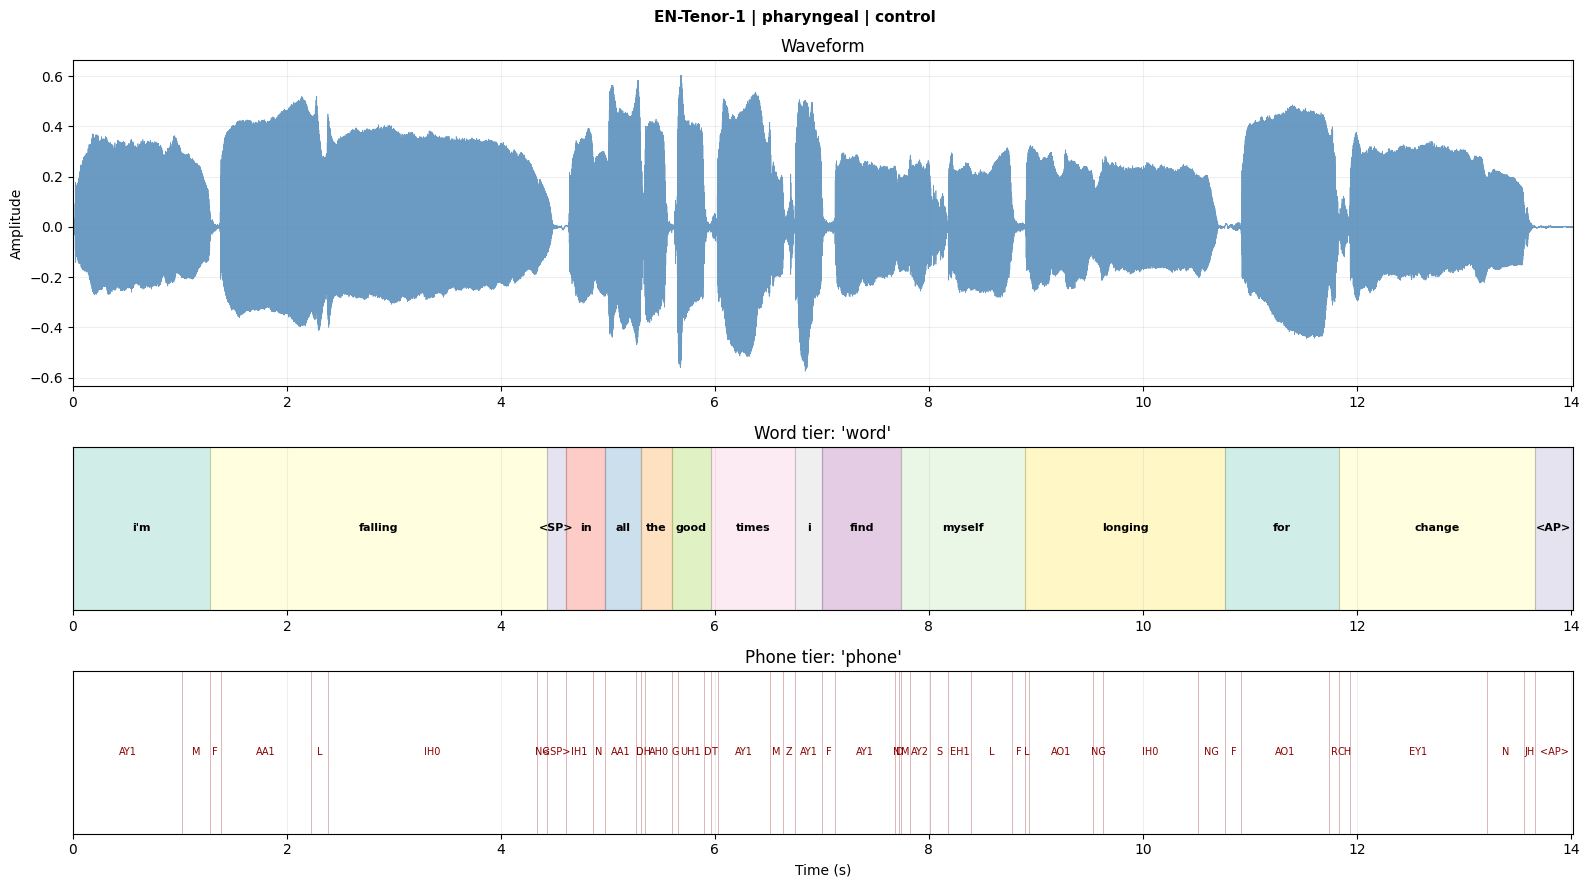


--- TECHNIQUE ---
Singer: EN-Tenor-1, Technique: pharyngeal
GT Lyrics: i'm falling <AP> in all the good times i find myself longing for change <AP>


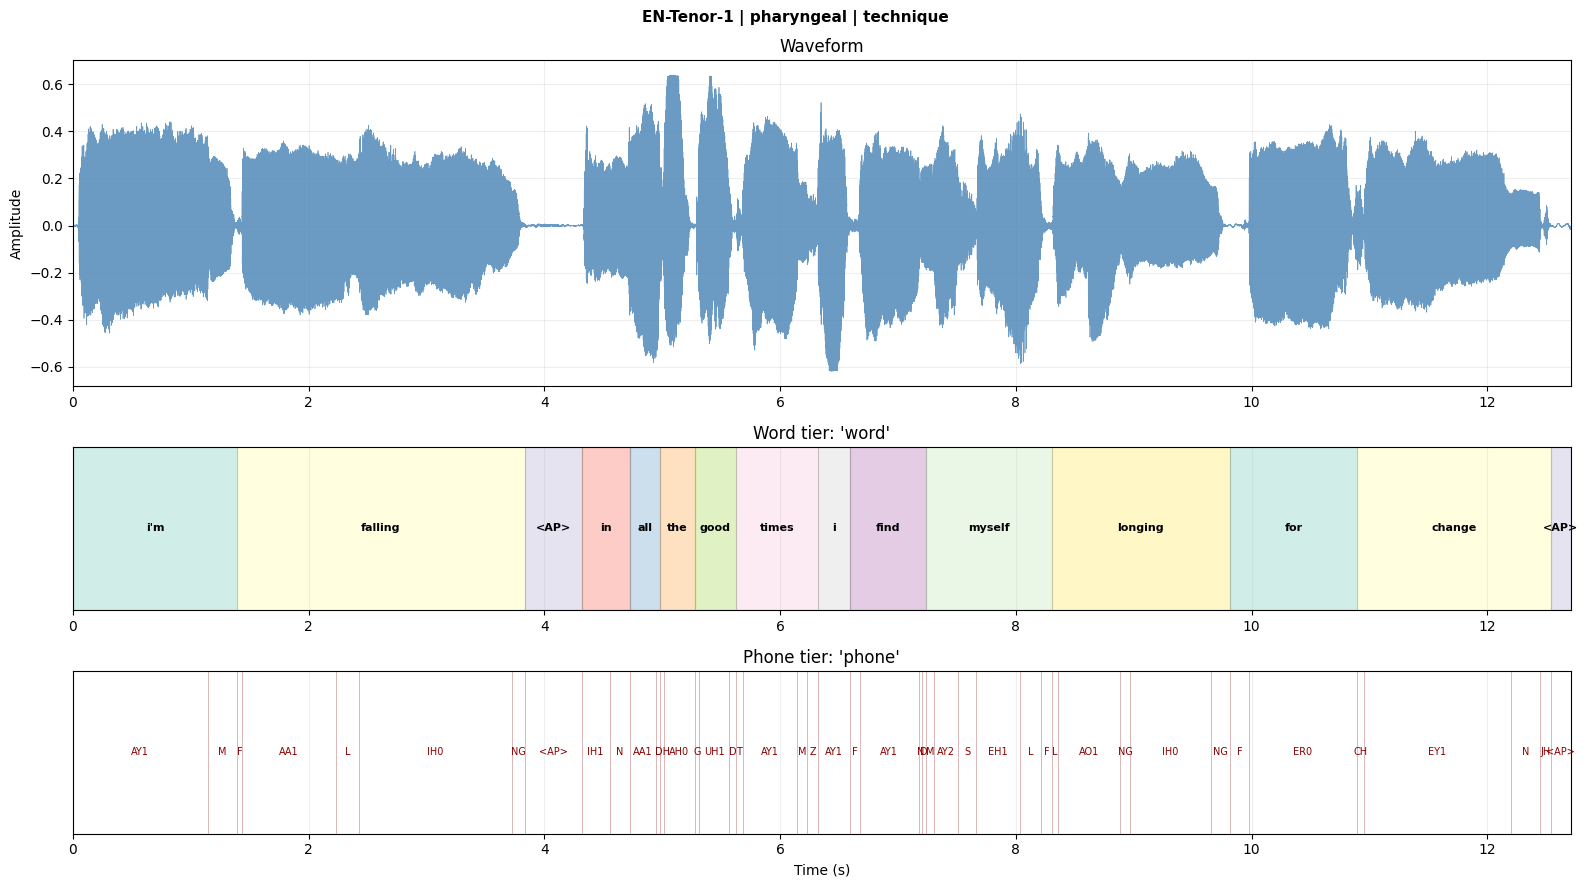


--- SPEECH ---
Singer: EN-Tenor-1, Technique: pharyngeal
GT Lyrics: i'm falling <SP> in all the good times i find myself longing for change <SP>


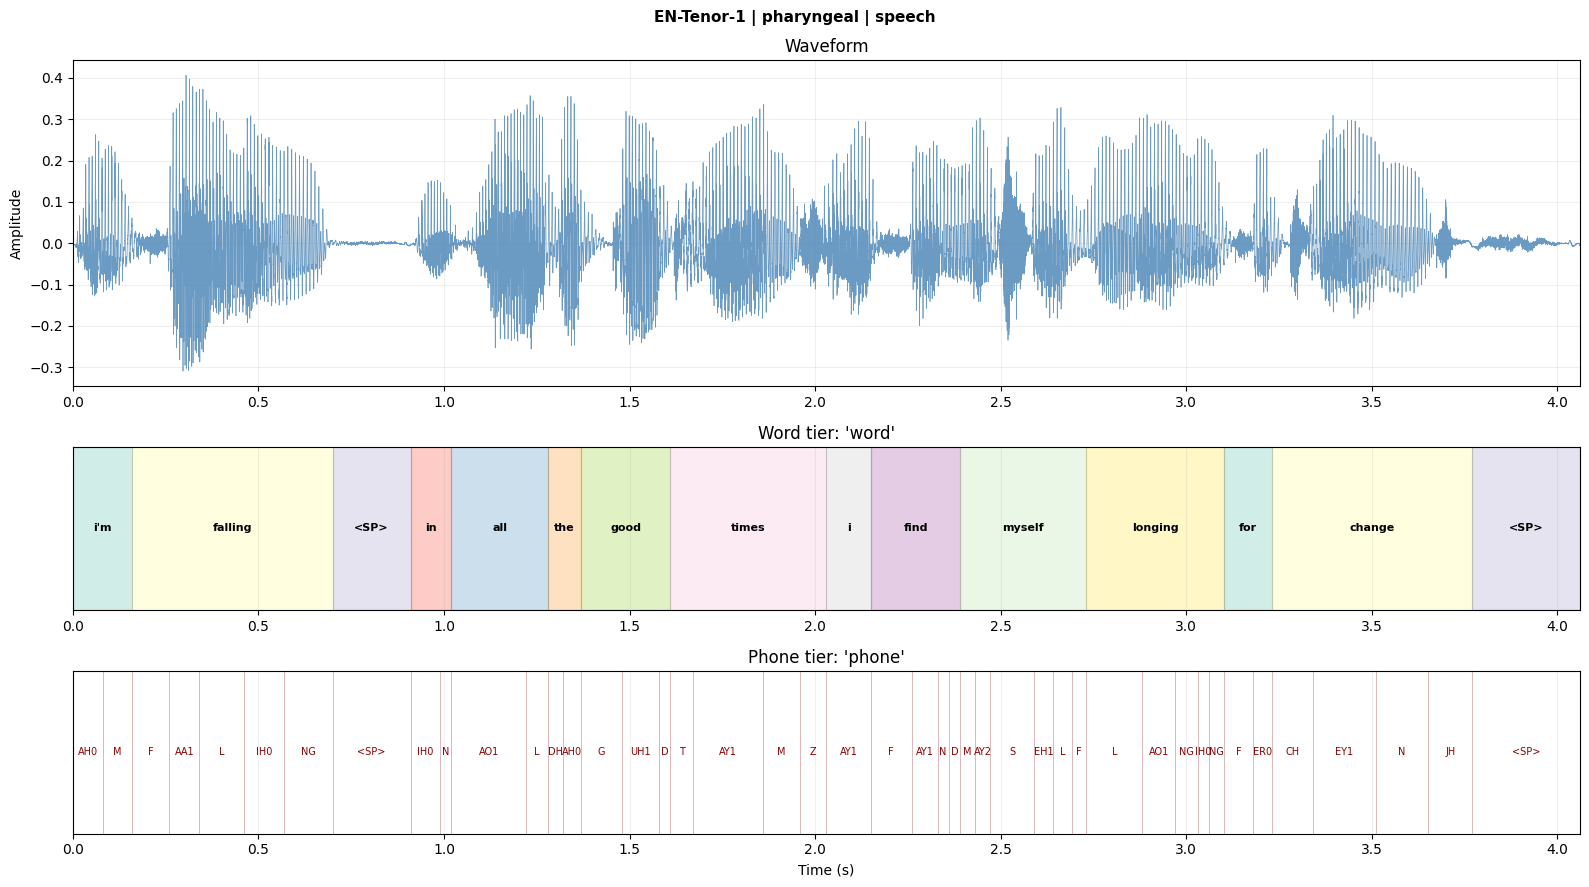

In [15]:
import pandas as pd

df = pd.read_csv(META_CSV)
# Filter utterances that have both wav and textgrid
sample = df[df["has_textgrid"] == True].dropna(subset=["tg_path"])

# Plot one example per group
for group in ["control", "technique", "speech"]:
    row = sample[sample["group"] == group].iloc[0]
    print(f"\n--- {group.upper()} ---")
    print(f"Singer: {row['singer_id']}, Technique: {row['technique']}")
    print(f"GT Lyrics: {row['gt_lyrics']}")
    try:
        plot_alignment(
            row["wav_path"],
            row["tg_path"],
            title=f"{row['singer_id']} | {row['technique']} | {group}"
        )
    except Exception as e:
        print(f"  Could not plot: {e}")

## 8. Technique Annotation Granularity

Are technique labels per-phoneme, per-word, or per-track?

In [16]:
# Find TextGrids from the Technique_Group folders (not Control)
technique_tgs = [p for p in all_tgs if any(
    kw in str(p) for kw in ["Vibrato_Group", "Glissando_Group", "Breathy_Group",
                              "Pharyngeal_Group", "Mixed_Voice_Group", "Falsetto_Group"]
)]
control_tgs = [p for p in all_tgs if "Control_Group" in str(p)]

print(f"Technique group TextGrids: {len(technique_tgs)}")
print(f"Control group TextGrids  : {len(control_tgs)}")

# Open a technique TextGrid and check for technique-specific tiers
if technique_tgs:
    example = technique_tgs[0]
    print(f"\nExample technique TG: {example.name}")
    tg = tgt.io.read_textgrid(str(example))
    for tier in tg.tiers:
        intervals = tier.intervals if hasattr(tier, 'intervals') else list(tier)
        non_empty = [iv for iv in intervals if iv.text.strip()]
        print(f"  Tier: '{tier.name}' — {len(non_empty)} annotations")
        print(f"    Labels: {list(set(iv.text for iv in non_empty))[:10]}")

Technique group TextGrids: 2083
Control group TextGrids  : 1563

Example technique TG: 0002.TextGrid
  Tier: 'word' — 28 annotations
    Labels: ['about', 'reasons', 'you', "i'd", 'for', 'run', 'would', 'be', 'hills', 'highway']
  Tier: 'phone' — 78 annotations
    Labels: ['Y', 'Z', 'IY0', 'T', 'R', 'K', 'UH1', 'S', 'AH0', 'ER0']
  Tier: 'mix' — 78 annotations
    Labels: ['0']
  Tier: 'falsetto' — 78 annotations
    Labels: ['0', '1']
  Tier: 'breathy' — 78 annotations
    Labels: ['0', '1']
  Tier: 'pharyngeal' — 78 annotations
    Labels: ['0']
  Tier: 'vibrato' — 78 annotations
    Labels: ['0']
  Tier: 'glissando' — 78 annotations
    Labels: ['0', '1']
  Tier: 'global' — 1 annotations
    Labels: ['pop, fast, medium, happy']


In [17]:
# Compare technique vs control TextGrid structures
print("=" * 50)
print("TECHNIQUE GROUP TextGrid structure:")
print("=" * 50)
if technique_tgs:
    tg = tgt.io.read_textgrid(str(technique_tgs[0]))
    for tier in tg.tiers:
        intervals = tier.intervals if hasattr(tier, 'intervals') else list(tier)
        non_empty = [iv for iv in intervals if iv.text.strip()]
        durations = [(iv.end_time - iv.start_time)*1000 for iv in non_empty]
        print(f"  '{tier.name}': {len(non_empty)} annotations",
              f"| avg {np.mean(durations):.0f}ms" if durations else "")

print()
print("=" * 50)
print("CONTROL GROUP TextGrid structure:")
print("=" * 50)
if control_tgs:
    tg = tgt.io.read_textgrid(str(control_tgs[0]))
    for tier in tg.tiers:
        intervals = tier.intervals if hasattr(tier, 'intervals') else list(tier)
        non_empty = [iv for iv in intervals if iv.text.strip()]
        durations = [(iv.end_time - iv.start_time)*1000 for iv in non_empty]
        print(f"  '{tier.name}': {len(non_empty)} annotations",
              f"| avg {np.mean(durations):.0f}ms" if durations else "")

TECHNIQUE GROUP TextGrid structure:
  'word': 28 annotations | avg 374ms
  'phone': 78 annotations | avg 134ms
  'mix': 78 annotations | avg 134ms
  'falsetto': 78 annotations | avg 134ms
  'breathy': 78 annotations | avg 134ms
  'pharyngeal': 78 annotations | avg 134ms
  'vibrato': 78 annotations | avg 134ms
  'glissando': 78 annotations | avg 134ms
  'global': 1 annotations | avg 10466ms

CONTROL GROUP TextGrid structure:
  'word': 28 annotations | avg 373ms
  'phone': 77 annotations | avg 135ms
  'mix': 77 annotations | avg 135ms
  'falsetto': 77 annotations | avg 135ms
  'breathy': 77 annotations | avg 135ms
  'pharyngeal': 77 annotations | avg 135ms
  'vibrato': 77 annotations | avg 135ms
  'glissando': 77 annotations | avg 135ms
  'global': 1 annotations | avg 10433ms


## 9. Coverage Summary

How many utterances have each type of annotation?

In [19]:
df = pd.read_csv(META_CSV)

print("=" * 60)
print("DATASET COVERAGE SUMMARY")
print("=" * 60)
print(f"Total utterances     : {len(df):,}")
print(f"With TextGrid        : {df['has_textgrid'].sum():,} ({df['has_textgrid'].mean():.1%})")
print(f"With MusicXML        : {df['has_musicxml'].sum():,} ({df['has_musicxml'].mean():.1%})")
print(f"With GT Lyrics       : {(df['gt_lyrics'].str.len() > 0).sum():,}")
print()
print("By group:")
print(df.groupby("group").agg(
    n=("wav_path", "count"),
    with_tg=("has_textgrid", "sum"),
    with_lyrics=("gt_lyrics", lambda x: (x.str.len() > 0).sum())
).to_string())
print()
print("By technique:")
print(df.groupby("technique").agg(
    n=("wav_path", "count"),
    with_tg=("has_textgrid", "sum"),
).to_string())

DATASET COVERAGE SUMMARY
Total utterances     : 6,892
With TextGrid        : 5,209 (75.6%)
With MusicXML        : 4,827 (70.0%)
With GT Lyrics       : 5,209

By group:
              n  with_tg  with_lyrics
group                                
control    2065     1563         1563
speech     2065     1563         1563
technique  2762     2083         2083

By technique:
                n  with_tg
technique                 
breathy      1083      882
glissando    1059      717
mixed_voice  2797     2080
pharyngeal   1047      855
vibrato       906      675


## 10. Save Analysis Results to Drive

In [22]:
# Save TextGrid analysis
df_tg.to_csv(META_DIR / "textgrid_analysis.csv", index=False)
print(f"TextGrid analysis: {META_DIR / 'textgrid_analysis.csv'}")

# Save phoneme duration analysis
ph_summary = df_ph.groupby(["group", "technique", "is_vowel"])["dur_ms"].agg(
    mean="mean", median="median", std="std", count="count"
).round(2).reset_index()
ph_summary.to_csv(META_DIR / "phoneme_duration_analysis.csv", index=False)
print(f"Phoneme analysis: {META_DIR / 'phoneme_duration_analysis.csv'}")

print("\nAll done!")

TextGrid analysis: /content/drive/MyDrive/atlas/metadata2/textgrid_analysis.csv
Phoneme analysis: /content/drive/MyDrive/atlas/metadata2/phoneme_duration_analysis.csv

All done!
